In [81]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
print("Libraries Loaded!")
df = pd.read_excel("data.xlsx")

Libraries Loaded!


In [82]:
import numpy as np

df["salary"] = np.where(
    df["salary_rate"] == "year",
    df["salary_year_avg"],
    df["salary_hour_avg"] * 2080
)

In [83]:
df.isnull().sum()

job_title_short              0
job_title                    0
job_location                55
job_country                  0
job_via                     10
job_schedule_type          123
job_work_from_home           0
search_location              0
job_posted_date              0
job_no_degree_mention        0
job_health_insurance         0
salary_rate                  0
salary_year_avg           9279
salary_hour_avg          20206
company_name                 0
job_skills                   0
salary                       0
dtype: int64

In [84]:
df.drop(columns=["salary_rate","salary_year_avg","salary_hour_avg"], inplace=True)

In [ ]:
df.info()

In [85]:
df.head()

,job_title_short,job_title,job_location,job_country,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,company_name,job_skills,salary
0,Data Scientist,"Data Scientist, Data Platform Sciences","San Francisco, CA",United States,via Snagajob,Full-time and Part-time,False,"California, United States",2023-11-01 18:02:42,False,False,Pinterest,"['airflow', 'git']",111040.804443
1,Data Scientist,Lead Data Scientist,"San Francisco, CA",United States,via IT JobServe,Full-time,False,"California, United States",2023-04-14 20:03:13,False,False,Navient,"['airflow', 'looker', 'tableau']",215049.000000
2,Senior Data Engineer,Senior Data Engineer,"San Francisco, CA",United States,via LinkedIn,Full-time,False,"Texas, United States",2023-12-08 11:06:48,True,True,Jobot,"['airflow', 'pyspark', 'pandas', 'looker', 'git']",225000.000000
3,Senior Data Engineer,Senior Data Engineer,"San Francisco, CA",United States,via LinkedIn,Full-time,False,"Illinois, United States",2023-11-18 11:06:10,False,True,Jobot,"['airflow', 'pyspark', 'pandas', 'looker', 'git']",225000.000000
4,Data Analyst,Data Analyst (Cyprus),"Limassol, Cyprus",Cyprus,via Ai-Jobs.net,Full-time,False,Cyprus,2023-04-13 13:42:27,True,False,capital.com,"['airflow', 'tableau', 'power bi', 'git']",102500.000000


In [86]:
df.isnull().sum()

job_title_short            0
job_title                  0
job_location              55
job_country                0
job_via                   10
job_schedule_type        123
job_work_from_home         0
search_location            0
job_posted_date            0
job_no_degree_mention      0
job_health_insurance       0
company_name               0
job_skills                 0
salary                     0
dtype: int64

In [87]:
df["job_location"] = df["job_location"].fillna(df["job_country"])

In [88]:
(df.isnull().sum() / len(df)) * 100

job_title_short          0.000000
job_title                0.000000
job_location             0.000000
job_country              0.000000
job_via                  0.033916
job_schedule_type        0.417161
job_work_from_home       0.000000
search_location          0.000000
job_posted_date          0.000000
job_no_degree_mention    0.000000
job_health_insurance     0.000000
company_name             0.000000
job_skills               0.000000
salary                   0.000000
dtype: float64

In [89]:
# rows where NOT null
df_not_null = df[df["job_via"].notnull()]

# rows where null
df_null = df[df["job_via"].isnull()]

In [90]:
df_not_null["salary"].describe()


count     29475.000000
mean     116078.347613
std       47912.550824
min       15000.000000
25%       84780.000000
50%      112320.000000
75%      145600.000000
max      960000.000000
Name: salary, dtype: float64

In [91]:
df_null["salary"].describe()

count       10.0
mean     31200.0
std          0.0
min      31200.0
25%      31200.0
50%      31200.0
75%      31200.0
max      31200.0
Name: salary, dtype: float64

<Axes: xlabel='salary', ylabel='Density'>

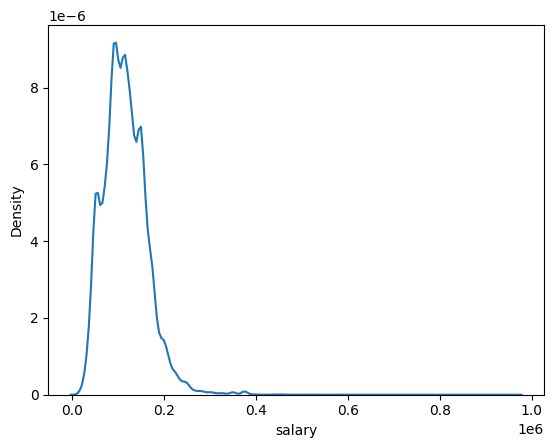

In [92]:
import seaborn as sns

sns.kdeplot(df_not_null["salary"], label="not null")


<Axes: xlabel='salary', ylabel='Density'>

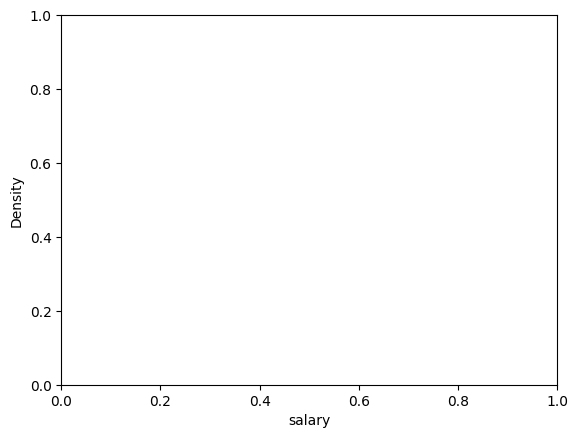

In [93]:
sns.kdeplot(df_null["salary"], label="null")

In [94]:
# job_via (low missing)
df["job_via"].fillna(df["job_via"].mode()[0], inplace=True)

# job_schedule_type (moderate missing)
df["job_schedule_type"].fillna("Unknown", inplace=True)

In [95]:
df.isnull().sum()

job_title_short          0
job_title                0
job_location             0
job_country              0
job_via                  0
job_schedule_type        0
job_work_from_home       0
search_location          0
job_posted_date          0
job_no_degree_mention    0
job_health_insurance     0
company_name             0
job_skills               0
salary                   0
dtype: int64

In [96]:
df["job_via"].nunique()

545

In [97]:
df["job_country"].nunique()

108

In [98]:
df["job_title"].nunique()

13675

In [99]:
df["job_title_short"].nunique()

10

In [100]:
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

In [101]:
df["month"] = df["job_posted_date"].dt.month
df["week"] = df["job_posted_date"].dt.isocalendar().week

In [102]:
df["month"] = df["job_posted_date"].dt.month
df["week"] = df["job_posted_date"].dt.isocalendar().week

In [103]:
df.groupby("month")["salary"].mean()

month
1     115785.554737
2     120612.388349
3     120633.078780
4     118927.146161
5     118988.877712
6     118663.670307
7     119073.926661
8     111948.983930
9     108806.282666
10    111441.915025
11    111816.266189
12    113897.359098
Name: salary, dtype: float64

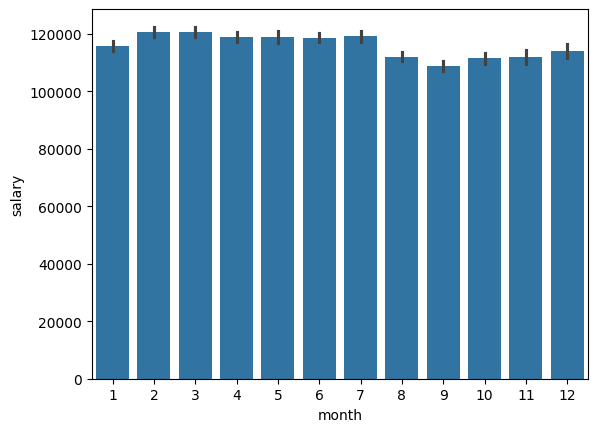

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="month", y="salary", data=df)
plt.show()

In [105]:
df.groupby("week")["salary"].mean()

week
1     108199.270653
2     121850.542429
3     115774.082562
4     116682.452726
5     120470.672528
6     120098.184231
7     122911.306321
8     119858.499864
9     119461.356565
10    119871.758237
11    124489.276708
12    119419.512410
13    117808.396657
14    114580.339983
15    120446.012285
16    121888.418810
17    119042.477502
18    120533.253265
19    116536.242056
20    119614.562274
21    121355.489945
22    120233.395127
23    114828.297566
24    121200.713073
25    118201.709228
26    118962.716580
27    118613.095890
28    117889.031960
29    116733.675426
30    122626.672978
31    114656.054478
32    111653.191678
33    112662.732649
34    111111.383537
35    110188.866175
36    112997.405737
37    107594.763506
38    103590.720654
39    110383.243975
40    112992.808785
41    111495.662119
42    117843.441834
43    107451.360560
44    110299.327992
45    108953.101678
46    112485.717555
47    108752.646322
48    115103.068795
49    114535.331819
50    109983.07

In [106]:
df["quarter"] = df["job_posted_date"].dt.quarter

In [107]:
df.groupby("quarter")["salary"].mean()

quarter
1    118886.320114
2    118845.998969
3    113312.168519
4    112313.641086
Name: salary, dtype: float64

In [108]:
df["company_name"].nunique()

9264

In [109]:
df.nunique()

job_title_short             10
job_title                13675
job_location              2397
job_country                108
job_via                    545
job_schedule_type           27
job_work_from_home           2
search_location            113
job_posted_date          28764
job_no_degree_mention        2
job_health_insurance         2
company_name              9264
job_skills               15618
salary                    3508
month                       12
week                        52
quarter                      4
dtype: int64

In [110]:
def extract_level(title):
    title = str(title).lower()
    if "senior" in title:
        return "senior"
    elif "junior" in title:
        return "junior"
    elif "lead" in title:
        return "lead"
    else:
        return "mid"

df["seniority"] = df["job_title"].apply(extract_level)

In [111]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["job_skills"] = df["job_skills"].apply(lambda x: " ".join(eval(x)))

In [112]:
cols = ["job_work_from_home","job_no_degree_mention","job_health_insurance"]

df[cols] = df[cols].astype(int)

In [113]:
df.drop(columns=["job_via","search_location","job_posted_date"], inplace=True)

In [114]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from category_encoders import TargetEncoder

In [115]:
preprocessor = ColumnTransformer(
    transformers=[
        
        # One-hot
        ("cat", OneHotEncoder(handle_unknown="ignore"), 
         ["job_title_short","job_schedule_type","seniority","quarter"]),
        
        # Target encoding
        ("target", TargetEncoder(), 
         ["company_name","job_country","job_location"]),
        
        # TF-IDF
        ("text", TfidfVectorizer(max_features=100), "job_skills"),
        
    ],
    remainder="drop"
)

In [116]:
preprocessor1 = ColumnTransformer(
    transformers=[
        
        # One-hot
        ("cat", OneHotEncoder(handle_unknown="ignore"), 
         ["job_title_short","job_schedule_type","seniority","quarter"]),
        
        # Target encoding
        ("target", TargetEncoder(), 
         ["company_name","job_country","job_location"]),
        
        # TF-IDF
        ("text", TfidfVectorizer(max_features=100,), "job_skills"),
        
    ],
    remainder="drop"
)

In [117]:
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

In [118]:
df["salary"] = (df["salary"] / 100).round() * 100

In [119]:
from sklearn.model_selection import train_test_split

X = df.drop("salary", axis=1)
y = df["salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [120]:
pipeline.fit(X_train, y_train)

# =========================
# EVALUATION
# =========================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MsE:", mse)
print("R2:", r2)




RMSE: 36398.75619174881
MsE: 1324869452.3063726
R2: 0.41785259738558644


In [121]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=5,
    scoring="neg_root_mean_squared_error",
    cv=2,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(X_train, y_train)

print("Best Params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)

# =========================
# FINAL MODEL
# =========================
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MsE:", mse)
print("R2:", r2)



Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': None}
Best CV RMSE: 40408.06746315109
RMSE: 36460.65130631619
MsE: 1329379093.6807764
R2: 0.41587106176465305


In [122]:
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [123]:
pipeline.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('target', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [124]:
y_pred_log = pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)

In [125]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MsE:", mse)
print("R2:", r2)

RMSE: 36656.20131335814
MsE: 1343677094.725439
R2: 0.4095885226388254


In [126]:
from xgboost import XGBRegressor

pipeline = Pipeline([
    ("preprocessor", preprocessor1),
    ("model", XGBRegressor())
])

In [127]:
pipeline.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('target', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [128]:
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [ ]:
y_pred = pipeline.predict(X_test)
#y_pred = np.expm1(y_pred_log)

In [130]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MsE:", mse)
print("R2:", r2)

RMSE: 36849.852103246354
MsE: 1357911600.0311296
R2: 0.40333388352945254


In [131]:
from xgboost import XGBRegressor

pipeline = Pipeline([
    ("preprocessor", preprocessor1),
    ("model", RandomForestRegressor())
])

In [132]:
pipeline.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('target', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [133]:
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [134]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MsE:", mse)
print("R2:", r2)

RMSE: 36849.852103246354
MsE: 1357911600.0311296
R2: 0.40333388352945254


In [135]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from category_encoders import TargetEncoder

preprocessor3 = ColumnTransformer(
    transformers=[
        
        # One-hot encoding
        ("cat", OneHotEncoder(handle_unknown="ignore"), 
         ["job_title_short","job_schedule_type","seniority","quarter","month"]),
        
        # Target encoding
        ("target", TargetEncoder(), 
         ["company_name","job_country","job_location"]),
        
        # Text
        ("text", TfidfVectorizer(max_features=100), "job_skills"),
        
        # Numeric / boolean (IMPORTANT)
        ("num", "passthrough", 
         ["job_work_from_home","job_no_degree_mention","job_health_insurance"])
        
    ],
    remainder="drop"
)

In [136]:
from xgboost import XGBRegressor

pipeline = Pipeline([
    ("preprocessor", preprocessor3),
    ("model", RandomForestRegressor())
])

In [137]:
pipeline.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('target', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [140]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('target', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [141]:
import numpy as np

#y_train_log = np.log1p(y_train)
y_test_log = y_test

In [142]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MsE:", mse)
print("R2:", r2)

RMSE: 36849.852103246354
MsE: 1357911600.0311296
R2: 0.40333388352945254
